# Scenario: Paddy Yield Prediction using Linear Regression

This notebook is prepared for the **Linear Regression** part of the group assignment (Supervised Learning).

## Dataset Source
UCI Machine Learning Repository: Paddy Dataset
https://archive.ics.uci.edu/dataset/1186/paddy+dataset

## Objective
Predict **Paddy yield(in Kg)** using cultivation, environmental, and weather-related features.

## Algorithm Used
- Linear Regression (non-deep-learning supervised regression)

## Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R2 (Coefficient of Determination)

In [1]:
# If needed, run this once in the notebook:
# %pip install -q pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# RMSE helper compatible across sklearn versions
try:
    from sklearn.metrics import root_mean_squared_error

    def rmse(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)
except Exception:

    def rmse(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [3]:
# Load dataset
df = pd.read_csv('paddydataset.csv', skipinitialspace=True)

# Clean column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
)

print('Shape:', df.shape)
df.head()

Shape: (2789, 45)


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


Missing values (top 10):


Hectares                     0
Agriblock                    0
Variety                      0
Soil Types                   0
Seedrate(in Kg)              0
LP_Mainfield(in Tonnes)      0
Nursery                      0
Nursery area (Cents)         0
LP_nurseryarea(in Tonnes)    0
DAP_20days                   0
dtype: int64

Duplicate rows: 451


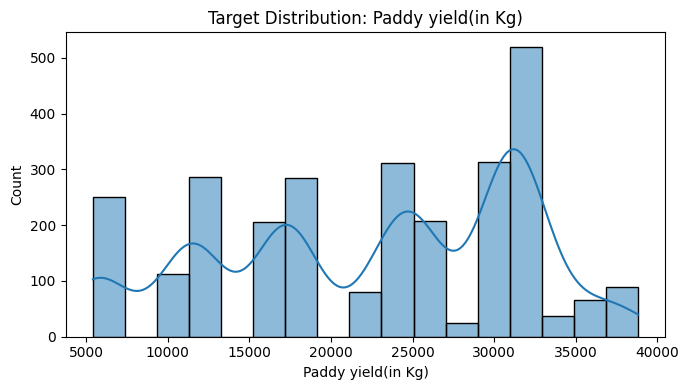

In [4]:
# Basic data checks
target_col = 'Paddy yield(in Kg)'
assert target_col in df.columns, 'Target column not found. Check dataset columns.'

print('Missing values (top 10):')
display(df.isna().sum().sort_values(ascending=False).head(10))

print('Duplicate rows:', df.duplicated().sum())

plt.figure(figsize=(7, 4))
sns.histplot(df[target_col], kde=True)
plt.title('Target Distribution: Paddy yield(in Kg)')
plt.tight_layout()
plt.show()

In [5]:
# Split features and target
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Ensure categorical text is cleaned
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype(str).str.strip()

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Categorical features:', len(categorical_features))
print('Numeric features:', len(numeric_features))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape, y_train.shape)
print('Test size :', X_test.shape, y_test.shape)

Categorical features: 8
Numeric features: 36
Train size: (2231, 44) (2231,)
Test size : (558, 44) (558,)


In [6]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

In [7]:
# Build and train Linear Regression model
linear_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse_val = rmse(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE : {mae:.3f}')
print(f'RMSE: {rmse_val:.3f}')
print(f'R2  : {r2:.4f}')

MAE : 698.319
RMSE: 927.936
R2  : 0.9894


In [8]:
# 5-fold cross-validation (report-friendly)
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_result = cross_validate(linear_model, X_train, y_train, cv=kf, scoring=scoring)

cv_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Mean': [
        -cv_result['test_MAE'].mean(),
        -cv_result['test_RMSE'].mean(),
        cv_result['test_R2'].mean()
    ],
    'Std': [
        cv_result['test_MAE'].std(),
        cv_result['test_RMSE'].std(),
        cv_result['test_R2'].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,MAE,714.956675,31.120226
1,RMSE,937.534833,31.452697
2,R2,0.989691,0.000603


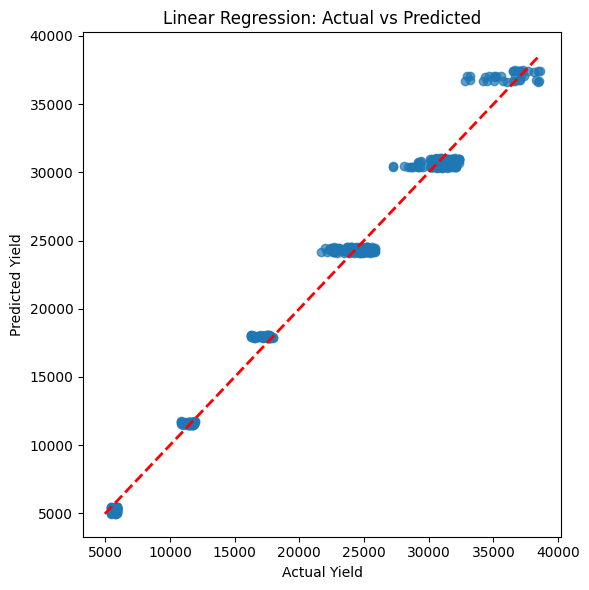

In [9]:
# Predicted vs Actual plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

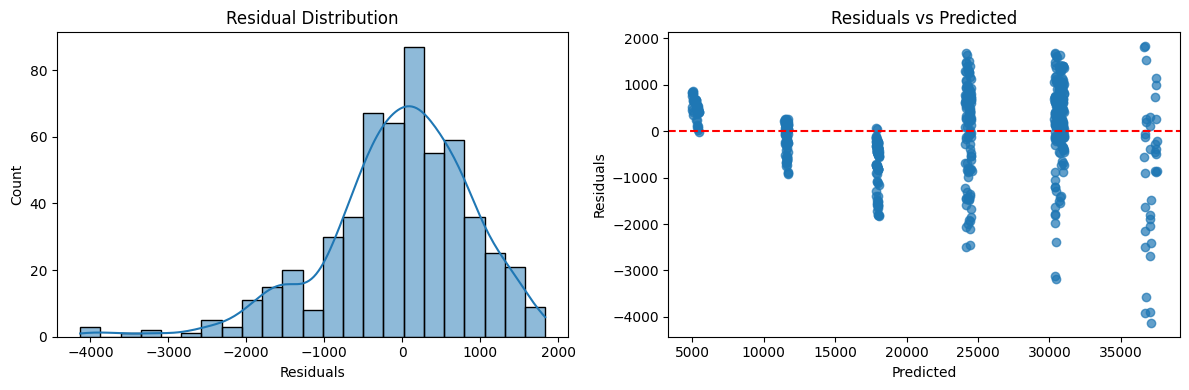

In [10]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residuals')

axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()